# Titanic Survival Prediction System
# Model Evaluation

## Objectives

- Evaluate the best-performing model
- Generate Confusion Matrix
- Generate Classification Report
- Understand model performance

## 1. Import Libraries

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
 )
import matplotlib.pyplot as plt

## Load Dataset

In [11]:
df = pd.read_csv("../data/Titanic-Dataset.csv")

In [12]:
# Remove unnecessary columns
df.drop(
    columns=["PassengerId", "Name", "Ticket", "Cabin"],
    inplace=True
)

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Encode categorical variables
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

## Prepare Features and Target

In [13]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Best Model

In [14]:
# Use the best-performing model from training
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

## Accuracy Score

In [15]:
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy : {accuracy:.2%}")

Accuracy : 82.68%


## Confusion Matrix

In [16]:
cm = confusion_matrix(y_test, predictions)
cm

array([[92, 13],
       [18, 56]], dtype=int64)

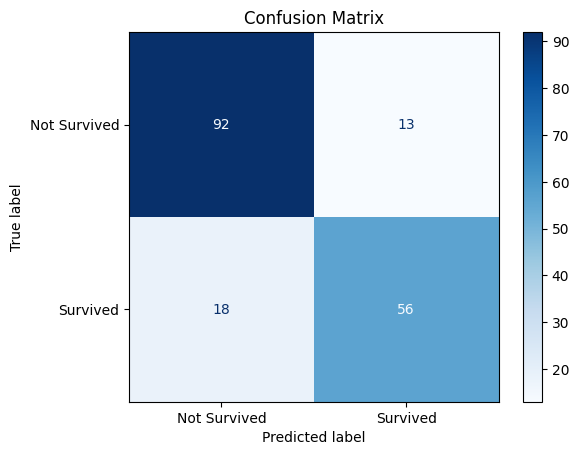

In [17]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Survived", "Survived"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## Classification Report

In [18]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



## Interpretation

### Precision
Precision tells us how many predicted survivors were actually survivors.

### Recall
Recall tells us how many actual survivors the model correctly identified.

### F1-Score
F1-score balances Precision and Recall.

### Accuracy
Overall percentage of correct predictions.

# Evaluation Summary

- Accuracy calculated
- Confusion Matrix generated
- Classification Report generated
- Model evaluated successfully